In [150]:
import pandas as pd

In [152]:
df = pd.read_csv(r"T:\Python datasets\HR_Analytics\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [154]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [156]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [158]:
cols = ['EmployeeCount', 'EmployeeNumber','Over18','StandardHours']

In [160]:
df = df.drop(df[cols],axis=1)

In [162]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [164]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])


In [166]:
cons = ['MaritalStatus', 'OverTime','Gender']
Or = OrdinalEncoder()
df[cons] = Or.fit_transform(df[cons])


In [168]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [170]:
categorical_cols = ['Department','EducationField', 'JobRole','BusinessTravel']
ct = ColumnTransformer(transformers=[('encode',OneHotEncoder(sparse_output=False),categorical_cols)],remainder='passthrough')
k = ct.fit_transform(df)
mf = pd.DataFrame(k,columns=ct.get_feature_names_out(),index=df.index)



In [172]:
mf.columns

Index(['encode__Department_Human Resources',
       'encode__Department_Research & Development', 'encode__Department_Sales',
       'encode__EducationField_Human Resources',
       'encode__EducationField_Life Sciences',
       'encode__EducationField_Marketing', 'encode__EducationField_Medical',
       'encode__EducationField_Other',
       'encode__EducationField_Technical Degree',
       'encode__JobRole_Healthcare Representative',
       'encode__JobRole_Human Resources',
       'encode__JobRole_Laboratory Technician', 'encode__JobRole_Manager',
       'encode__JobRole_Manufacturing Director',
       'encode__JobRole_Research Director',
       'encode__JobRole_Research Scientist', 'encode__JobRole_Sales Executive',
       'encode__JobRole_Sales Representative',
       'encode__BusinessTravel_Non-Travel',
       'encode__BusinessTravel_Travel_Frequently',
       'encode__BusinessTravel_Travel_Rarely', 'remainder__Age',
       'remainder__Attrition', 'remainder__DailyRate',
       'r

In [174]:
scale_cols = [ 'remainder__Age','remainder__DailyRate',
       'remainder__DistanceFromHome', 'remainder__Education',
       'remainder__EnvironmentSatisfaction',
       'remainder__HourlyRate', 'remainder__JobInvolvement',
       'remainder__JobLevel', 'remainder__JobSatisfaction','remainder__MonthlyIncome',
       'remainder__MonthlyRate', 'remainder__NumCompaniesWorked',
       'remainder__PercentSalaryHike',
       'remainder__RelationshipSatisfaction',
       'remainder__StockOptionLevel', 'remainder__TotalWorkingYears',
       'remainder__TrainingTimesLastYear', 'remainder__WorkLifeBalance',
       'remainder__YearsAtCompany', 'remainder__YearsInCurrentRole',
       'remainder__YearsSinceLastPromotion',
       'remainder__YearsWithCurrManager']

In [176]:
# Using Normalization.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
mf[scale_cols] = scaler.fit_transform(mf[scale_cols])

In [178]:
y = mf['remainder__Attrition']


In [180]:
x = mf.drop('remainder__Attrition',axis=1)

In [182]:
print(df['Department'].unique())
print(df['EducationField'].unique())
print(df['JobRole'].unique())
print(df['BusinessTravel'].unique())

['Sales' 'Research & Development' 'Human Resources']
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']


In [184]:
mf.head()

,encode__Department_Human Resources,encode__Department_Research & Development,encode__Department_Sales,encode__EducationField_Human Resources,encode__EducationField_Life Sciences,encode__EducationField_Marketing,encode__EducationField_Medical,encode__EducationField_Other,encode__EducationField_Technical Degree,encode__JobRole_Healthcare Representative,...,remainder__PerformanceRating,remainder__RelationshipSatisfaction,remainder__StockOptionLevel,remainder__TotalWorkingYears,remainder__TrainingTimesLastYear,remainder__WorkLifeBalance,remainder__YearsAtCompany,remainder__YearsInCurrentRole,remainder__YearsSinceLastPromotion,remainder__YearsWithCurrManager
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.000000,0.000000,0.200,0.0,0.000000,0.15,0.222222,0.000000,0.294118
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,1.000000,0.333333,0.250,0.5,0.666667,0.25,0.388889,0.066667,0.411765
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,0.333333,0.000000,0.175,0.5,0.666667,0.00,0.000000,0.000000,0.000000
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.666667,0.000000,0.200,0.5,0.666667,0.20,0.388889,0.200000,0.000000
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,1.000000,0.333333,0.150,0.5,0.666667,0.05,0.111111,0.133333,0.117647


In [186]:
mf.head()

,encode__Department_Human Resources,encode__Department_Research & Development,encode__Department_Sales,encode__EducationField_Human Resources,encode__EducationField_Life Sciences,encode__EducationField_Marketing,encode__EducationField_Medical,encode__EducationField_Other,encode__EducationField_Technical Degree,encode__JobRole_Healthcare Representative,...,remainder__PerformanceRating,remainder__RelationshipSatisfaction,remainder__StockOptionLevel,remainder__TotalWorkingYears,remainder__TrainingTimesLastYear,remainder__WorkLifeBalance,remainder__YearsAtCompany,remainder__YearsInCurrentRole,remainder__YearsSinceLastPromotion,remainder__YearsWithCurrManager
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.000000,0.000000,0.200,0.0,0.000000,0.15,0.222222,0.000000,0.294118
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,1.000000,0.333333,0.250,0.5,0.666667,0.25,0.388889,0.066667,0.411765
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,0.333333,0.000000,0.175,0.5,0.666667,0.00,0.000000,0.000000,0.000000
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.666667,0.000000,0.200,0.5,0.666667,0.20,0.388889,0.200000,0.000000
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,1.000000,0.333333,0.150,0.5,0.666667,0.05,0.111111,0.133333,0.117647


In [188]:
### Training the model 

In [190]:
from sklearn.model_selection import train_test_split

In [192]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=1,stratify=y)

In [194]:
### Fitting logistic regression 

In [196]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced',max_iter=1000)
lr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [198]:
### Checking the accuracy of the model 


In [200]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns

In [202]:
y_train_pred = lr.predict(x_train)
y_test_pred = lr.predict(x_test)

In [204]:
print(accuracy_score(y_test,y_test_pred))


0.717687074829932


In [206]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81       247
         1.0       0.33      0.77      0.46        47

    accuracy                           0.72       294
   macro avg       0.64      0.74      0.64       294
weighted avg       0.84      0.72      0.75       294



In [208]:
cm = confusion_matrix(y_test,y_test_pred)
cm

array([[175,  72],
       [ 11,  36]], dtype=int64)

<Axes: >

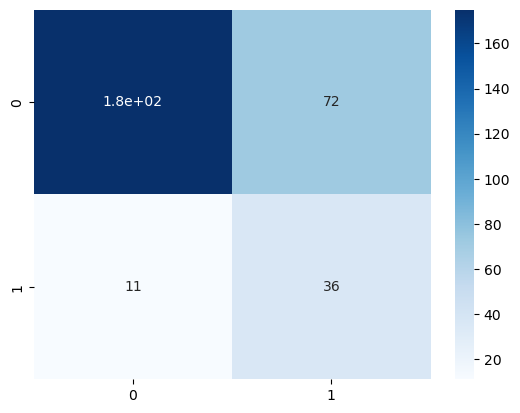

In [210]:
sns.heatmap(cm,annot=True,cmap='Blues',edgecolor = 'black')